# Preprocessing and Windowing - Charité Dataset

**Objective:** Prepare data for FoG detection through label creation, 3-second sliding windows, and LOSO splits.

**Process:**
1. Load dataset
2. Create binary labels
3. Generate sliding windows (3s at 200 Hz, train 50% overlap / test 0% overlap)
4. Create LOSO splits
5. Save windowed data

In [6]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from sklearn.model_selection import LeaveOneGroupOut
import pickle

from loaders import ChariteDatasetLoader
from processing import WindowCreator, SignalCleaner

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Load Dataset

In [7]:
# Load data (both feet merged per trial — simultaneous placement)
loader = ChariteDatasetLoader('../../Datasets/Charité–Universitätsmedizin Berlin/Data Sheet 2/data')
df = loader.load_all_data(verbose=True)

# Add subject and trial string identifiers
df['subject'] = df['subject_id'].apply(lambda x: f'S{x:02d}')
df['trial'] = df['trial_id'].apply(lambda x: f'T{x}')

print(f"\nDataset shape: {df.shape}")
print(f"Subjects: {sorted(df['subject'].unique())}")
print(f"Total samples: {len(df):,}")

📁 Encontrados 32 trials
📊 Cargando datos del dataset Charité-Universitätsmedizin...



Cargando trials:   0%|          | 0/32 [00:00<?, ?it/s]

Cargando trials: 100%|██████████| 32/32 [00:00<00:00, 48.23it/s]



✅ Dataset cargado exitosamente

RESUMEN DEL DATASET: ChariteDatasetLoader

📊 Información General:
   Dimensiones: (428195, 17)
   Filas: 428,195
   Columnas: 17
   Memoria: 79.10 MB

👥 Sujetos: 16

🚨 Episodios de FoG:
   Muestras con FoG: 288,190 (67.30%)
   Muestras sin FoG: 140,005 (32.70%)


Dataset shape: (428195, 19)
Subjects: ['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16']
Total samples: 428,195


## 2. Binary Labels

Charité dataset already has binary labels: 0=No FoG, 1=FoG

In [8]:
# Rename for consistency with pipeline
df['binary_label'] = df['fog_label']

print("Label distribution:")
label_counts = df['binary_label'].value_counts().sort_index()
for label, count in label_counts.items():
    pct = count / len(df) * 100
    print(f"  {['No FoG', 'FoG'][label]}: {count:,} ({pct:.1f}%)")

Label distribution:
  No FoG: 140,005 (32.7%)
  FoG: 288,190 (67.3%)


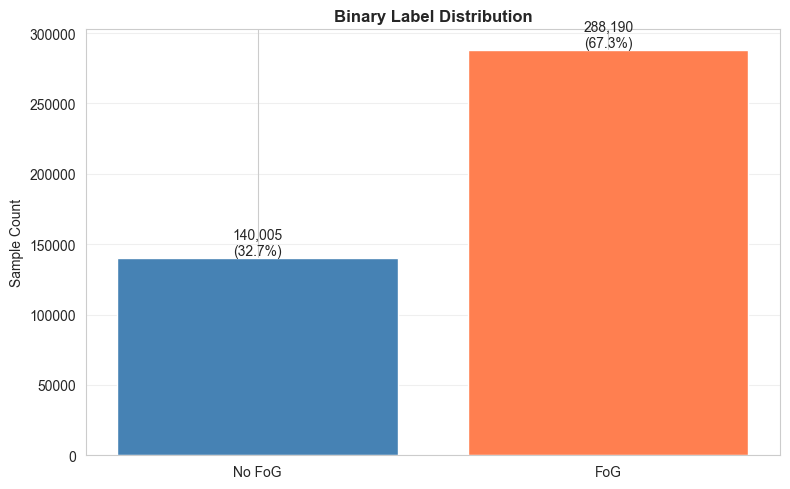

In [9]:
# Visualize label distribution
fig, ax = plt.subplots(figsize=(8, 5))

binary_counts = df['binary_label'].value_counts().sort_index()
ax.bar(['No FoG', 'FoG'], binary_counts.values, color=['steelblue', 'coral'])
ax.set_ylabel('Sample Count')
ax.set_title('Binary Label Distribution', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(binary_counts.values):
    pct = v / len(df) * 100
    ax.text(i, v, f'{v:,}\n({pct:.1f}%)', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 3. Define Feature Columns and Parameters

In [10]:
# Charité-specific parameters
SAMPLING_RATE = 200  # Hz
WINDOW_SIZE_SEC = 4.0  # 4 seconds for better FoG capture at 200Hz (800 samples)
WINDOW_OVERLAP_TRAIN = 0.75  # 75% overlap for training (more FoG windows)
WINDOW_OVERLAP_TEST = 0.0  # 0% overlap for testing
WINDOW_LABEL_STRATEGY = 'min_positive_ratio'
WINDOW_LABEL_MIN_POSITIVE_RATIO = 0.15  # lower threshold to capture FoG transitions

# Feature columns: ambos pies — convención {sensor}_{eje}_{posición_corporal}
FEATURE_COLUMNS = [
    'acc_x_left_foot', 'acc_y_left_foot', 'acc_z_left_foot',
    'gyr_x_left_foot', 'gyr_y_left_foot', 'gyr_z_left_foot',
    'acc_x_right_foot', 'acc_y_right_foot', 'acc_z_right_foot',
    'gyr_x_right_foot', 'gyr_y_right_foot', 'gyr_z_right_foot',
]

print(f"Sampling rate: {SAMPLING_RATE} Hz")
print(f"Window size: {WINDOW_SIZE_SEC}s ({int(WINDOW_SIZE_SEC * SAMPLING_RATE)} samples)")
print(f"Train overlap: {WINDOW_OVERLAP_TRAIN*100:.0f}%")
print(f"Test overlap: {WINDOW_OVERLAP_TEST*100:.0f}%")
print(f"Label strategy: {WINDOW_LABEL_STRATEGY} (threshold={WINDOW_LABEL_MIN_POSITIVE_RATIO})")
print(f"Feature columns ({len(FEATURE_COLUMNS)}): {FEATURE_COLUMNS}")

Sampling rate: 200 Hz
Window size: 4.0s (800 samples)
Train overlap: 75%
Test overlap: 0%
Label strategy: min_positive_ratio (threshold=0.15)
Feature columns (12): ['acc_x_left_foot', 'acc_y_left_foot', 'acc_z_left_foot', 'gyr_x_left_foot', 'gyr_y_left_foot', 'gyr_z_left_foot', 'acc_x_right_foot', 'acc_y_right_foot', 'acc_z_right_foot', 'gyr_x_right_foot', 'gyr_y_right_foot', 'gyr_z_right_foot']


## 3.1 Conservative Signal Cleaning and Trial-wise Normalization

Before windowing, apply conservative preprocessing to reduce subject/session drift without aggressively smoothing FoG dynamics:

- interpolate sparse missing values and outliers with the existing `SignalCleaner`
- detrend each trial/channel to reduce slow drift and gravity-like offsets
- apply robust trial-wise normalization using median and IQR
- clip extreme normalized values to limit residual spikes

In [11]:
PREPROCESSING_CONFIG = {
    'apply_cleaning': True,
    'interpolate_outliers': True,
    'interpolate_missing': True,
    'bandpass_filter': True,       # NEW: bandpass filter for 200Hz data
    'bandpass_low_freq': 0.5,      # Hz
    'bandpass_high_freq': 25.0,    # Hz (Nyquist=100Hz, keep gait-relevant frequencies)
    'detrend_signals': True,
    'robust_normalize_per_trial': True,
    'clip_after_normalization': 8.0,
}

cleaner = SignalCleaner()

def preprocess_trial_signals(df_in, feature_cols, subject_col='subject', trial_col='trial'):
    processed_parts = []

    for (_, _), group_df in df_in.groupby([subject_col, trial_col], sort=False):
        group_df = group_df.copy()
        group_df.loc[:, feature_cols] = group_df[feature_cols].astype(float)
        values = group_df[feature_cols].replace([np.inf, -np.inf], np.nan).to_numpy(dtype=float)

        if PREPROCESSING_CONFIG['apply_cleaning']:
            values = cleaner.clean_windows(
                values[np.newaxis, :, :],
                interpolate_outliers=PREPROCESSING_CONFIG['interpolate_outliers'],
                interpolate_missing=PREPROCESSING_CONFIG['interpolate_missing']
            )[0]

        # Bandpass filter: removes gravity/DC offset and high-freq noise
        if PREPROCESSING_CONFIG['bandpass_filter'] and values.shape[0] >= 50:
            values = SignalCleaner.bandpass_filter_signal(
                values,
                sampling_rate=SAMPLING_RATE,
                low_freq=PREPROCESSING_CONFIG['bandpass_low_freq'],
                high_freq=PREPROCESSING_CONFIG['bandpass_high_freq'],
                order=4
            )

        if PREPROCESSING_CONFIG['detrend_signals'] and values.shape[0] >= 3:
            values = signal.detrend(values, axis=0, type='linear')

        if PREPROCESSING_CONFIG['robust_normalize_per_trial']:
            median = np.nanmedian(values, axis=0)
            q25 = np.nanpercentile(values, 25, axis=0)
            q75 = np.nanpercentile(values, 75, axis=0)
            iqr = q75 - q25
            std = np.nanstd(values, axis=0)
            scale = np.where(iqr > 1e-6, iqr, np.where(std > 1e-6, std, 1.0))
            values = (values - median) / scale

        clip_value = PREPROCESSING_CONFIG['clip_after_normalization']
        if clip_value is not None:
            values = np.clip(values, -clip_value, clip_value)

        group_df.loc[:, feature_cols] = values
        processed_parts.append(group_df)

    return pd.concat(processed_parts, ignore_index=True)

df = preprocess_trial_signals(df, FEATURE_COLUMNS)

print('Preprocessing complete:')
for key, value in PREPROCESSING_CONFIG.items():
    print(f"  - {key}: {value}")
print(f"  Remaining NaNs in signal columns: {int(df[FEATURE_COLUMNS].isna().sum().sum())}")

Preprocessing complete:
  - apply_cleaning: True
  - interpolate_outliers: True
  - interpolate_missing: True
  - bandpass_filter: True
  - bandpass_low_freq: 0.5
  - bandpass_high_freq: 25.0
  - detrend_signals: True
  - robust_normalize_per_trial: True
  - clip_after_normalization: 8.0
  Remaining NaNs in signal columns: 0


## 4. Create Sliding Windows for Visualization

In [12]:
# Create window creator for visualization
window_creator = WindowCreator(
    window_size=WINDOW_SIZE_SEC,
    overlap=WINDOW_OVERLAP_TRAIN,
    sampling_rate=SAMPLING_RATE,
    label_strategy=WINDOW_LABEL_STRATEGY,
    positive_labels=[1],
    min_positive_ratio=WINDOW_LABEL_MIN_POSITIVE_RATIO
)

# Display configuration
config = window_creator.get_window_info()
print("Window Configuration:")
print(f"  Duration: {config['window_size_sec']} seconds")
print(f"  Samples: {config['window_samples']}")
print(f"  Overlap: {config['overlap']*100}%")
print(f"  Step: {config['step_samples']} samples")
print(f"  Label strategy: {config['label_strategy']} (threshold={config['min_positive_ratio']:.2f})")

Window Configuration:
  Duration: 4.0 seconds
  Samples: 800
  Overlap: 75.0%
  Step: 200 samples
  Label strategy: min_positive_ratio (threshold=0.15)


In [13]:
# Create windows for one subject (visualization)
subject_sample = 'S01'
df_sample = df[df['subject'] == subject_sample].reset_index(drop=True)

windows_sample, labels_sample, subjects_sample = window_creator.create_windows_per_subject(
    df=df_sample,
    feature_cols=FEATURE_COLUMNS,
    label_col='binary_label',
    subject_col='subject',
    trial_col='trial'
)

print(f"\nSample windows created for {subject_sample}:")
print(f"  Windows shape: {windows_sample.shape}")
print(f"  Label distribution: {np.bincount(labels_sample)}")


Sample windows created for S01:
  Windows shape: (59, 800, 12)
  Label distribution: [32 27]


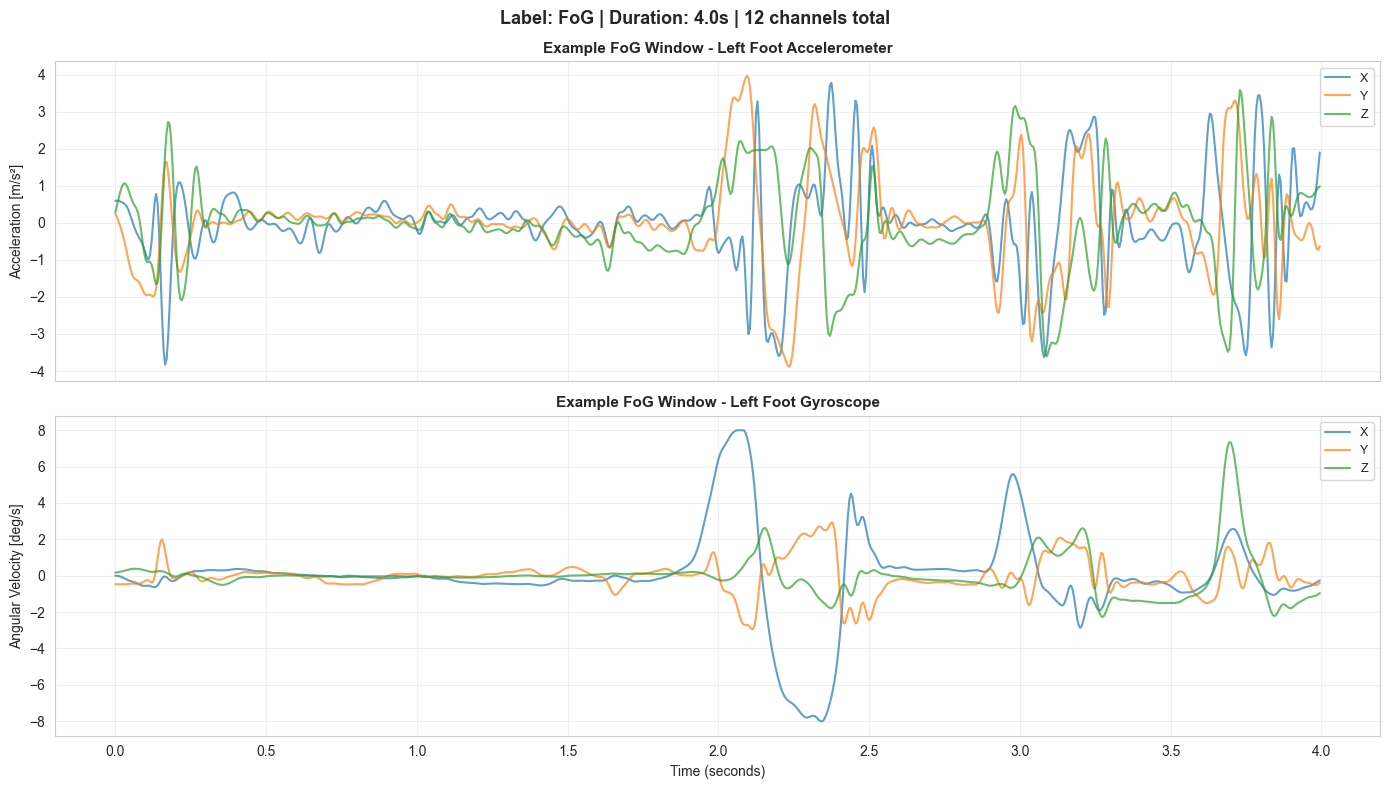

In [14]:
# Visualize example window (left foot channels: 0-5)
# Channel order: acc_x_lf, acc_y_lf, acc_z_lf, gyr_x_lf, gyr_y_lf, gyr_z_lf,
#                acc_x_rf, acc_y_rf, acc_z_rf, gyr_x_rf, gyr_y_rf, gyr_z_rf
fog_indices = np.where(labels_sample == 1)[0]
if len(fog_indices) > 0:
    idx = fog_indices[0]
    example_window = windows_sample[idx]
    example_label = labels_sample[idx]

    n_samples, n_channels = example_window.shape
    time_axis = np.arange(n_samples) / SAMPLING_RATE

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Left foot accelerometer (channels 0-2)
    axes[0].plot(time_axis, example_window[:, 0], label='X', alpha=0.7)
    axes[0].plot(time_axis, example_window[:, 1], label='Y', alpha=0.7)
    axes[0].plot(time_axis, example_window[:, 2], label='Z', alpha=0.7)
    axes[0].set_ylabel('Acceleration [m/s²]')
    axes[0].set_title('Example FoG Window - Left Foot Accelerometer', fontsize=11, fontweight='bold')
    axes[0].legend(loc='upper right', fontsize=9)
    axes[0].grid(True, alpha=0.3)

    # Left foot gyroscope (channels 3-5)
    axes[1].plot(time_axis, example_window[:, 3], label='X', alpha=0.7)
    axes[1].plot(time_axis, example_window[:, 4], label='Y', alpha=0.7)
    axes[1].plot(time_axis, example_window[:, 5], label='Z', alpha=0.7)
    axes[1].set_ylabel('Angular Velocity [deg/s]')
    axes[1].set_xlabel('Time (seconds)')
    axes[1].set_title('Example FoG Window - Left Foot Gyroscope', fontsize=11, fontweight='bold')
    axes[1].legend(loc='upper right', fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Label: FoG | Duration: {WINDOW_SIZE_SEC}s | {n_channels} channels total',
                fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No FoG windows found in sample.")

## 5. Create LOSO Splits with Different Overlap for Train/Test

**Strategy:**
- **Train windows:** 50% overlap (more training data)
- **Test windows:** 0% overlap (realistic evaluation, no temporal correlation)

This ensures proper evaluation without overestimating performance due to overlapping windows in test set.

In [15]:
# Create LOSO splits with different overlap for train/test
print("Creating LOSO splits with improved FoG-sensitive preprocessing...")
print("  Train: 50% overlap (more data)")
print("  Test: 0% overlap (realistic evaluation)")
print(f"  Label strategy: {WINDOW_LABEL_STRATEGY} (threshold={WINDOW_LABEL_MIN_POSITIVE_RATIO:.2f})")
print("="*70)

# Get unique subjects
subjects = sorted(df['subject'].unique())
n_splits = len(subjects)

# Create window creators
window_creator_train = WindowCreator(
    window_size=WINDOW_SIZE_SEC,
    overlap=WINDOW_OVERLAP_TRAIN,
    sampling_rate=SAMPLING_RATE,
    label_strategy=WINDOW_LABEL_STRATEGY,
    positive_labels=[1],
    min_positive_ratio=WINDOW_LABEL_MIN_POSITIVE_RATIO
)

window_creator_test = WindowCreator(
    window_size=WINDOW_SIZE_SEC,
    overlap=WINDOW_OVERLAP_TEST,
    sampling_rate=SAMPLING_RATE,
    label_strategy=WINDOW_LABEL_STRATEGY,
    positive_labels=[1],
    min_positive_ratio=WINDOW_LABEL_MIN_POSITIVE_RATIO
)

loso_splits_binary = []

for fold, test_subject in enumerate(subjects):
    print(f"\nFold {fold}: Test Subject = {test_subject}")
    
    # Split dataframe into train and test subjects
    train_subjects = [s for s in subjects if s != test_subject]
    
    df_train = df[df['subject'].isin(train_subjects)].reset_index(drop=True)
    df_test = df[df['subject'] == test_subject].reset_index(drop=True)
    
    # Create train windows with 50% overlap
    X_train_windows, y_train, train_subjects_arr = window_creator_train.create_windows_per_subject(
        df=df_train,
        feature_cols=FEATURE_COLUMNS,
        label_col='binary_label',
        subject_col='subject',
        trial_col='trial'
    )
    
    # Create test windows with 0% overlap
    X_test_windows, y_test, test_subjects_arr = window_creator_test.create_windows_per_subject(
        df=df_test,
        feature_cols=FEATURE_COLUMNS,
        label_col='binary_label',
        subject_col='subject',
        trial_col='trial'
    )
    
    # Create split info
    split_info = {
        'fold': fold,
        'test_subject': test_subject,
        'X_train': X_train_windows,
        'X_test': X_test_windows,
        'y_train': y_train,
        'y_test': y_test,
        'subjects_train': train_subjects_arr,
        'subjects_test': test_subjects_arr,
        'train_dist': np.bincount(y_train, minlength=2),
        'test_dist': np.bincount(y_test, minlength=2)
    }
    loso_splits_binary.append(split_info)
    
    print(f"  Train: {X_train_windows.shape[0]} windows (50% overlap)")
    print(f"  Test:  {X_test_windows.shape[0]} windows (0% overlap)")
    print(f"  Train distribution: {split_info['train_dist']}")
    print(f"  Test distribution:  {split_info['test_dist']}")

print("\n" + "="*70)
print(f"Binary LOSO splits created: {len(loso_splits_binary)} folds")
print("="*70)

Creating LOSO splits with improved FoG-sensitive preprocessing...
  Train: 50% overlap (more data)
  Test: 0% overlap (realistic evaluation)
  Label strategy: min_positive_ratio (threshold=0.15)

Fold 0: Test Subject = S01
  Train: 1968 windows (50% overlap)
  Test:  15 windows (0% overlap)
  Train distribution: [ 290 1678]
  Test distribution:  [9 6]

Fold 1: Test Subject = S02
  Train: 1739 windows (50% overlap)
  Test:  73 windows (0% overlap)
  Train distribution: [ 305 1434]
  Test distribution:  [ 5 68]

Fold 2: Test Subject = S03
  Train: 1446 windows (50% overlap)
  Test:  146 windows (0% overlap)
  Train distribution: [ 297 1149]
  Test distribution:  [  5 141]

Fold 3: Test Subject = S04
  Train: 1984 windows (50% overlap)
  Test:  12 windows (0% overlap)
  Train distribution: [ 299 1685]
  Test distribution:  [8 4]

Fold 4: Test Subject = S05
  Train: 1966 windows (50% overlap)
  Test:  16 windows (0% overlap)
  Train distribution: [ 291 1675]
  Test distribution:  [9 7]

Fo

## 6. Visualize LOSO Splits

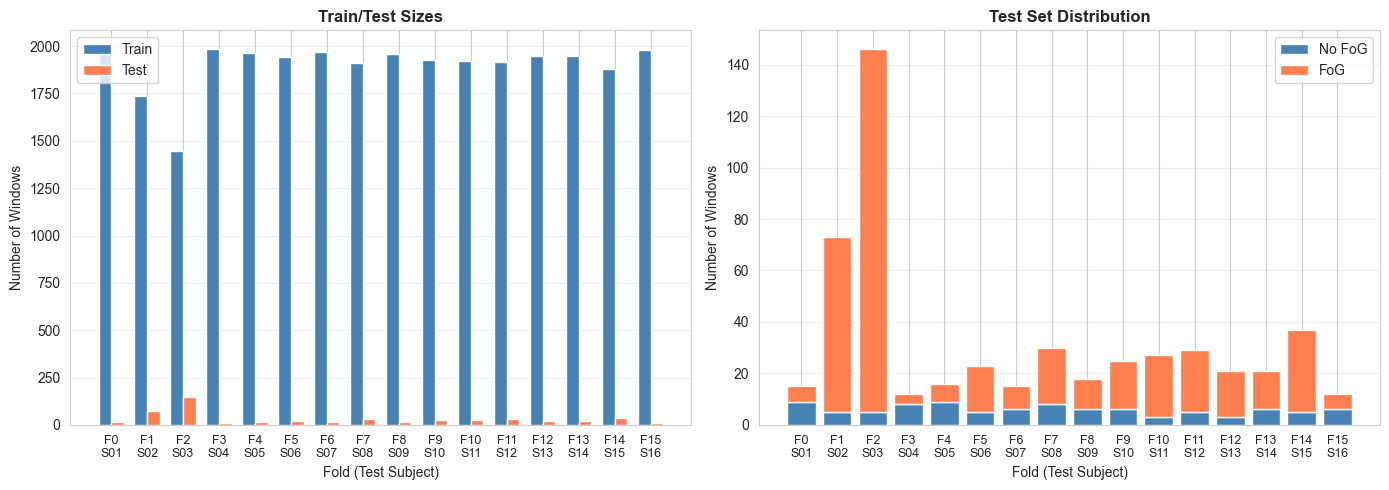

In [16]:
# Visualize LOSO splits
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train/Test sizes
train_sizes = [split['X_train'].shape[0] for split in loso_splits_binary]
test_sizes = [split['X_test'].shape[0] for split in loso_splits_binary]
test_subjects = [split['test_subject'] for split in loso_splits_binary]

x = np.arange(len(loso_splits_binary))
width = 0.35

axes[0].bar(x - width/2, train_sizes, width, label='Train', color='steelblue')
axes[0].bar(x + width/2, test_sizes, width, label='Test', color='coral')
axes[0].set_xlabel('Fold (Test Subject)')
axes[0].set_ylabel('Number of Windows')
axes[0].set_title('Train/Test Sizes', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"F{i}\n{s}" for i, s in enumerate(test_subjects)], fontsize=9)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Test distribution
for i, split in enumerate(loso_splits_binary):
    dist = split['test_dist']
    axes[1].bar(i, dist[0], color='steelblue', label='No FoG' if i == 0 else '')
    axes[1].bar(i, dist[1], bottom=dist[0], color='coral', label='FoG' if i == 0 else '')

axes[1].set_xlabel('Fold (Test Subject)')
axes[1].set_ylabel('Number of Windows')
axes[1].set_title('Test Set Distribution', fontweight='bold')
axes[1].set_xticks(range(len(loso_splits_binary)))
axes[1].set_xticklabels([f"F{i}\n{s}" for i, s in enumerate(test_subjects)], fontsize=9)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Summary Statistics

In [17]:
# Summary
total_train_bin = sum([split['X_train'].shape[0] for split in loso_splits_binary])
total_test_bin = sum([split['X_test'].shape[0] for split in loso_splits_binary])

print("="*70)
print("PREPROCESSING SUMMARY")
print("="*70)

print(f"\nOriginal dataset:")
print(f"  Samples: {len(df):,}")
print(f"  Subjects: {df['subject'].nunique()}")

print(f"\nSignal preprocessing:")
print(f"  Cleaning applied: {PREPROCESSING_CONFIG['apply_cleaning']}")
print(f"  Detrending: {PREPROCESSING_CONFIG['detrend_signals']}")
print(f"  Robust normalization per trial: {PREPROCESSING_CONFIG['robust_normalize_per_trial']}")
print(f"  Clipping after normalization: ±{PREPROCESSING_CONFIG['clip_after_normalization']}")

print(f"\nWindow creation strategy:")
print(f"  Train windows: {WINDOW_SIZE_SEC}s, 50% overlap")
print(f"  Test windows: {WINDOW_SIZE_SEC}s, 0% overlap (no temporal correlation)")
print(f"  Label threshold: {WINDOW_LABEL_MIN_POSITIVE_RATIO:.2f} positive ratio")
print(f"  Window shape: ({int(WINDOW_SIZE_SEC * SAMPLING_RATE)} samples, {len(FEATURE_COLUMNS)} features)")

print(f"\nLOSO splits:")
print(f"  Folds: {len(loso_splits_binary)}")
print(f"  Avg train windows/fold: {total_train_bin/len(loso_splits_binary):.0f}")
print(f"  Avg test windows/fold: {total_test_bin/len(loso_splits_binary):.0f}")

print(f"\nClass balance (binary):")
train_no_fog = sum([split['train_dist'][0] for split in loso_splits_binary])
train_fog = sum([split['train_dist'][1] for split in loso_splits_binary])
test_no_fog = sum([split['test_dist'][0] for split in loso_splits_binary])
test_fog = sum([split['test_dist'][1] for split in loso_splits_binary])

print(f"  Train - No FoG: {train_no_fog:,} ({train_no_fog/(train_no_fog+train_fog)*100:.1f}%)")
print(f"  Train - FoG: {train_fog:,} ({train_fog/(train_no_fog+train_fog)*100:.1f}%)")
print(f"  Test - No FoG: {test_no_fog:,} ({test_no_fog/(test_no_fog+test_fog)*100:.1f}%)")
print(f"  Test - FoG: {test_fog:,} ({test_fog/(test_no_fog+test_fog)*100:.1f}%)")

print("="*70)

PREPROCESSING SUMMARY

Original dataset:
  Samples: 428,195
  Subjects: 16

Signal preprocessing:
  Cleaning applied: True
  Detrending: True
  Robust normalization per trial: True
  Clipping after normalization: ±8.0

Window creation strategy:
  Train windows: 4.0s, 50% overlap
  Test windows: 4.0s, 0% overlap (no temporal correlation)
  Label threshold: 0.15 positive ratio
  Window shape: (800 samples, 12 features)

LOSO splits:
  Folds: 16
  Avg train windows/fold: 1900
  Avg test windows/fold: 32

Class balance (binary):
  Train - No FoG: 4,830 (15.9%)
  Train - FoG: 25,575 (84.1%)
  Test - No FoG: 95 (18.3%)
  Test - FoG: 425 (81.7%)


## 8. Save Processed Data

In [18]:
# Create output directory
output_dir = Path('../../outputs/datasets_csv')
output_dir.mkdir(parents=True, exist_ok=True)

# Save labeled dataset
csv_path = output_dir / 'charite_segmented_dataset.csv'
df.to_csv(csv_path, index=False)
print(f"Labeled dataset saved: {csv_path}")
print(f"  Samples: {len(df):,}")
print(f"  Columns: {len(df.columns)}")

# Save binary LOSO splits
binary_path = output_dir / 'charite_loso_windows_binary.pkl'
with open(binary_path, 'wb') as f:
    pickle.dump(loso_splits_binary, f)
print(f"\nBinary LOSO splits saved: {binary_path}")
print(f"  Folds: {len(loso_splits_binary)}")
print(f"  Total windows: {sum([len(s['y_train']) + len(s['y_test']) for s in loso_splits_binary]):,}")

print("\n" + "="*70)
print("All data saved successfully.")
print("="*70)

Labeled dataset saved: ..\..\outputs\datasets_csv\charite_segmented_dataset.csv
  Samples: 428,195
  Columns: 20

Binary LOSO splits saved: ..\..\outputs\datasets_csv\charite_loso_windows_binary.pkl
  Folds: 16
  Total windows: 30,925

All data saved successfully.


## Summary

**Completed preprocessing pipeline:**

1. Loaded Charité dataset (bilateral feet, 200 Hz sampling)
2. Used existing binary labels (0=No FoG, 1=FoG)
3. Applied conservative trial-wise signal preprocessing before windowing:
   - outlier and missing-value interpolation with `SignalCleaner`
   - linear detrending per trial/channel
   - robust normalization with median and IQR
   - clipping of extreme normalized values
4. Generated 3-second sliding windows with different overlap strategies:
   - **Train: 50% overlap** (more training data, 300-sample steps)
   - **Test: 0% overlap** (realistic evaluation, 600-sample steps)
5. Tightened window labeling using `min_positive_ratio = 0.30`
6. Created 16 LOSO folds for subject-independent validation
7. Saved cleaned labeled dataset and windowed LOSO splits

**Rationale for these changes:**
- stronger label threshold reduces ambiguous transition windows
- detrending and robust normalization reduce subject/session scale differences
- conservative interpolation avoids large gaps but limits distortion of FoG dynamics

**Data structure:**
- Train windows: shape (n_windows, 600, 12) with 50% overlap
- Test windows: shape (n_windows, 600, 12) with 0% overlap
- Windows maintain temporal continuity within subject/trial boundaries
- No data leakage: test subjects completely isolated in each fold

**Next step:** Feature extraction from windowed data (notebook 03)